# Persistence Diagrams on Financial Data
## First topological look at real market dynamics

This notebook applies persistent homology directly to financial return series for the first time in this project. Using the Takens embedding pipeline from `tda-financial-data-pipeline`, we compute persistence diagrams for S&P 500, TSLA, and BTC across different market regimes.

The goal is to understand what the **shape of financial returns** looks like topologically — and whether that shape changes before and during market crises.

In [1]:
import sys
sys.path.insert(0, '/home/gabo-linux/TDA-Gabo/tda-financial-data-pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import compute_log_returns, normalize
from src.embedding import takens_embedding
from src.data import fetch_ticker

# Load all three assets
sp500 = fetch_ticker('^GSPC', '2000-01-01', '2024-01-01')
tsla = fetch_ticker('TSLA', '2000-01-01', '2024-01-01')
btc = fetch_ticker('BTC-USD', '2000-01-01', '2024-01-01')

# Strip timezones
sp500.index = pd.to_datetime(sp500.index, utc=True).tz_localize(None)
tsla.index = pd.to_datetime(tsla.index, utc=True).tz_localize(None)
btc.index = pd.to_datetime(btc.index, utc=True).tz_localize(None)

# Compute normalized returns
sp500_r = normalize(compute_log_returns(sp500))
tsla_r = normalize(compute_log_returns(tsla))
btc_r = normalize(compute_log_returns(btc))

print(f"S&P 500: {len(sp500_r)} days")
print(f"TSLA:    {len(tsla_r)} days")
print(f"BTC:     {len(btc_r)} days")

Fetching ^GSPC from Yahoo Finance...
Cached to ../data/raw/GSPC_2000-01-01_2024-01-01.csv
Fetching TSLA from Yahoo Finance...
Cached to ../data/raw/TSLA_2000-01-01_2024-01-01.csv
Fetching BTC-USD from Yahoo Finance...
Cached to ../data/raw/BTC-USD_2000-01-01_2024-01-01.csv
S&P 500: 6036 days
TSLA:    3399 days
BTC:     3392 days


## Persistence Diagrams by Market Regime

We compute persistence diagrams on three distinct market periods for S&P 500:

- **Calm period** — 2005-2006 (pre-crisis bull market)
- **Crisis period** — 2008-2009 (Global Financial Crisis)
- **Recovery period** — 2010-2011 (post-crisis recovery)

Each period uses a 50-day window — consistent with Gidea & Katz (2018). The question: **does the topology change across regimes?**

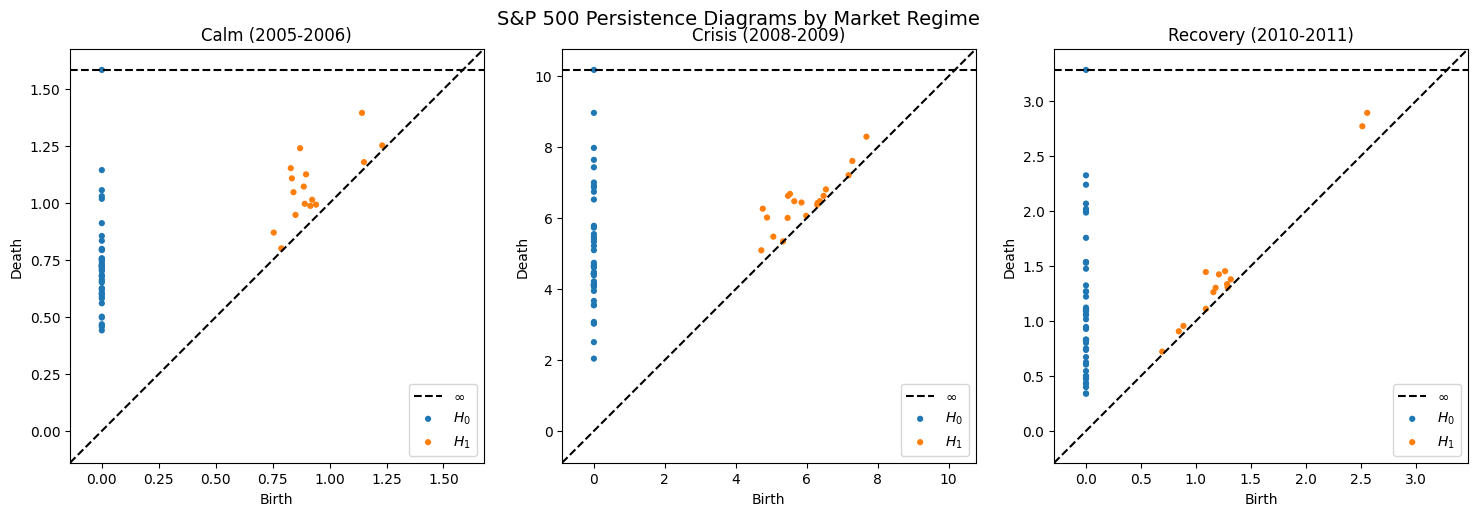

In [2]:
# Define three market regimes
regimes = {
    'Calm (2005-2006)':    ('2005-01-01', '2006-01-01'),
    'Crisis (2008-2009)':  ('2008-09-01', '2009-06-01'),
    'Recovery (2010-2011)': ('2010-01-01', '2011-01-01')
}

# Compute persistence diagrams for each regime
d = 5  # optimal embedding dimension from FNN

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

for ax, (regime, (start, end)) in zip(axes, regimes.items()):
    # Extract window
    window = sp500_r[start:end].values[:50]
    
    # Takens embedding
    X = takens_embedding(window, d)
    
    # Persistent homology
    diagrams = ripser(X)['dgms']
    
    # Plot
    plot_diagrams(diagrams, ax=ax, show=False)
    ax.set_title(regime)
    ax.set_facecolor('white')

plt.suptitle('S&P 500 Persistence Diagrams by Market Regime', fontsize=14)
plt.tight_layout()
plt.show()

## Observations

The persistence diagrams reveal a striking difference across market regimes:

| Regime | Filtration Scale | H1 Features |
|--------|-----------------|-------------|
| Calm (2005-2006) | ~1.5 | Many short-lived loops |
| Crisis (2008-2009) | ~10 | Same relative structure but at 6-7x larger scale |
| Recovery (2010-2011) | ~3 | Intermediate scale |

**Important:** the three diagrams have different axis scales — the crisis diagram extends to ~10 while the calm period only reaches ~1.5. This scale difference is not a rendering artifact — it reflects the true expansion of the filtration during crisis periods.

The **filtration scale expands dramatically during crisis** — extreme returns push points far apart in the embedding space, inflating the entire persistence diagram. This scale inflation is the topological signature of market stress and is directly captured by the $L^2$ norm of persistence landscapes.

## Persistence Diagrams — TSLA and BTC

We repeat the analysis for TSLA and BTC during the 2020 COVID crisis — the only period where all three assets overlap.

- **Pre-COVID** — 2019 (calm period)
- **COVID crash** — March-April 2020
- **Post-COVID** — 2021 (recovery/rally)

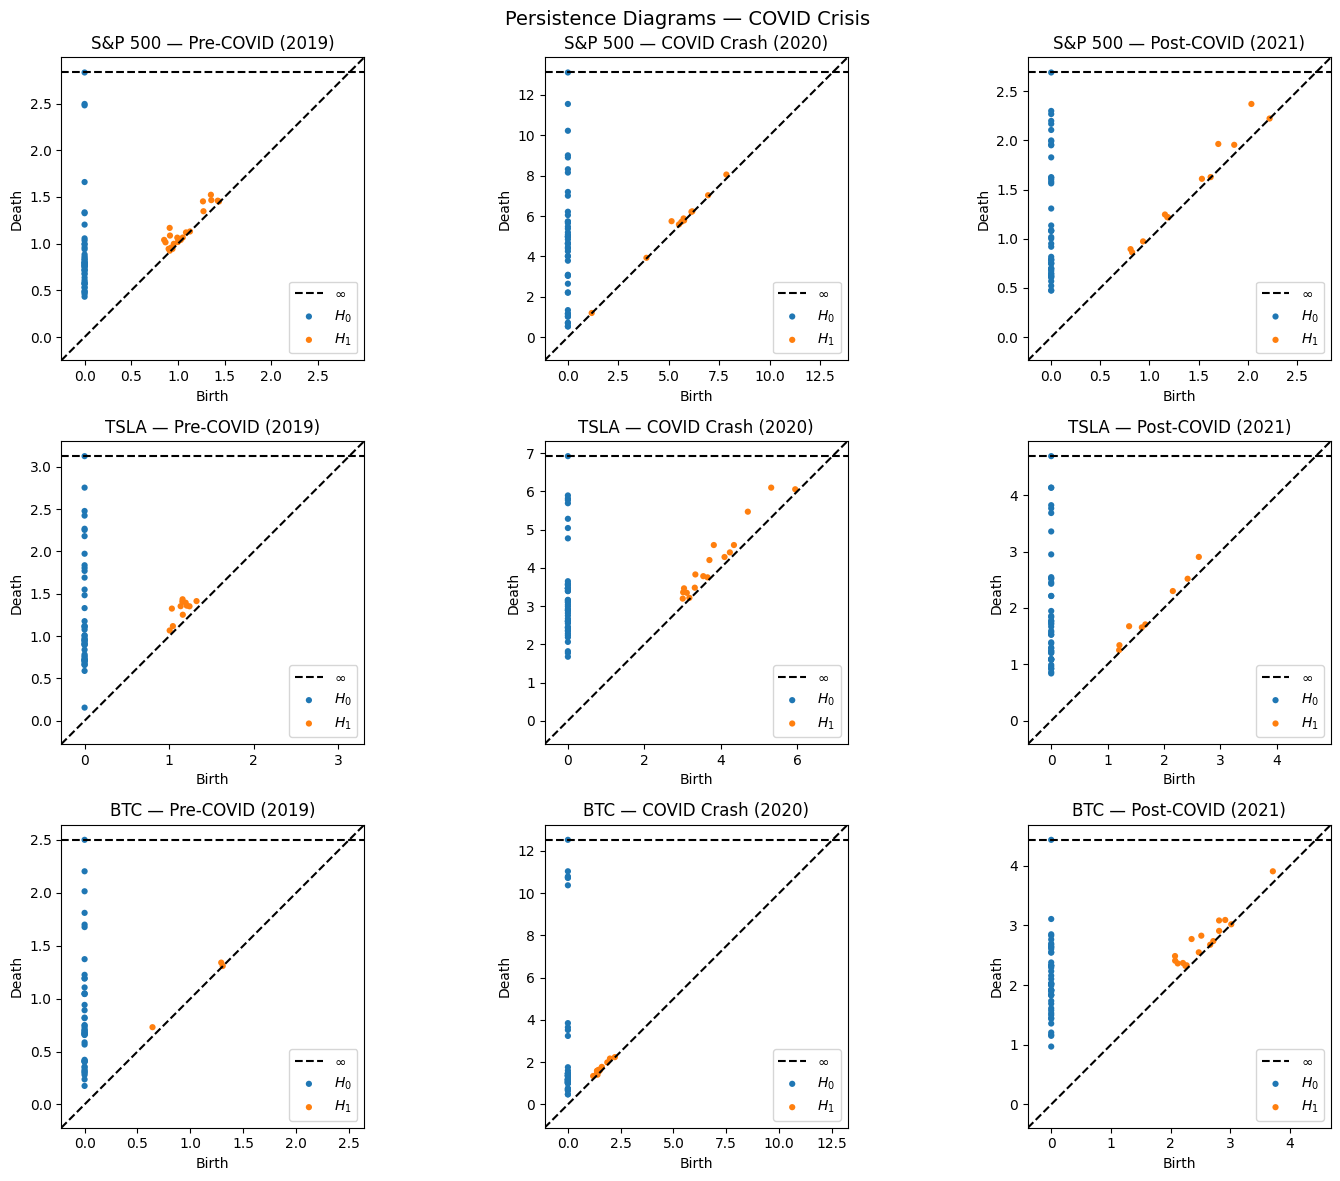

In [4]:
# Define COVID regimes for all three assets
covid_regimes = {
    'Pre-COVID (2019)':     ('2019-01-01', '2019-12-31'),
    'COVID Crash (2020)':   ('2020-02-01', '2020-06-01'),
    'Post-COVID (2021)':    ('2021-01-01', '2021-12-31')
}

d = 5
assets = [
    (sp500_r, 'S&P 500', 'steelblue'),
    (tsla_r, 'TSLA', 'darkorange'),
    (btc_r, 'BTC', 'green')
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), facecolor='white')

for row, (returns, asset_name, color) in enumerate(assets):
    for col, (regime, (start, end)) in enumerate(covid_regimes.items()):
        window = returns[start:end].values[:50]
        X = takens_embedding(window, d)
        diagrams = ripser(X)['dgms']
        
        plot_diagrams(diagrams, ax=axes[row, col], show=False)
        axes[row, col].set_title(f'{asset_name} — {regime}')
        axes[row, col].set_facecolor('white')

plt.suptitle('Persistence Diagrams — COVID Crisis', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Compute exact filtration scales (death of last H0 generator)
print("Exact filtration scales (death of last H0 generator):")
print(f"\n{'Asset':<10} {'Pre-COVID':>12} {'COVID Crash':>12} {'Post-COVID':>12}")
print("-" * 50)

for returns, asset_name in [(sp500_r, 'S&P 500'), (tsla_r, 'TSLA'), (btc_r, 'BTC')]:
    scales = []
    for start, end in [('2019-01-01', '2019-12-31'),
                       ('2020-02-01', '2020-06-01'),
                       ('2021-01-01', '2021-12-31')]:
        window = returns[start:end].values[:50]
        X = takens_embedding(window, d)
        diagrams = ripser(X)['dgms']
        
        # Death of last finite H0 generator
        h0 = diagrams[0]
        finite_h0 = h0[h0[:, 1] != np.inf]
        scale = finite_h0[:, 1].max() if len(finite_h0) > 0 else 0
        scales.append(scale)
    
    print(f"{asset_name:<10} {scales[0]:>12.4f} {scales[1]:>12.4f} {scales[2]:>12.4f}")

Exact filtration scales (death of last H0 generator):

Asset         Pre-COVID  COVID Crash   Post-COVID
--------------------------------------------------
S&P 500          2.4954      11.5546       2.3007
TSLA             2.7545       5.8938       4.1351
BTC              2.2033      11.0392       3.1067


## Observations

The persistence diagrams reveal of the three assets show some differences but also correlation:

| Asset | Pre-COVID Scale | COVID Crash Scale | Post-COVID Scale |
|-------|----------------|-------------------|-----------------|
| S&P 500 | 2.50 | 11.55 | 2.30 |
| TSLA | 2.75 | 5.89 | 4.14 |
| BTC | 2.20 | 11.04 | 3.11 |

We can see how the three **filtrations scale expand dramatically during the COVID crash**. This scale inflations are consistant with a market stress and is directly captured by the $L^2$ norm of persistence landscapes.

## Conclusions

Persistent homology reveals clear topological differences across market regimes:

- **All three assets** show dramatic filtration scale expansion during the COVID crash — confirming that extreme returns create topologically distinct point clouds
- **S&P 500** returns to pre-COVID scale post-crisis — the index normalized topologically
- **BTC and TSLA** remain elevated post-COVID — reflecting the extraordinary rally and decoupling from traditional markets
- **BTC and S&P 500** show similar crash scales (~11) — topological evidence of their correlation during the crash, consistent with observed price behavior

These static snapshots motivate the rolling window analysis in Notebook 02 — where we track the $L^2$ norm continuously over time to detect regime changes as they happen.